In [29]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

import camb
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import pysm3
import pysm3.units as u
import pandas as pd
from pathlib import Path
from astropy.table import Table, vstack
from tqdm.auto import tqdm
from pathlib import Path

In [30]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

mpl.rcParams['font.family']       = 'serif'
mpl.rcParams['font.serif']        = ['DejaVu Serif', 'Times New Roman', 'serif']
mpl.rcParams['mathtext.fontset']  = 'dejavuserif'   
mpl.rcParams['text.usetex']       = False            

mpl.rcParams['font.size']         = 14
mpl.rcParams['axes.titlesize']    = 15
mpl.rcParams['axes.labelsize']    = 14
mpl.rcParams['xtick.labelsize']   = 12
mpl.rcParams['ytick.labelsize']   = 12
mpl.rcParams['legend.fontsize']   = 12
mpl.rcParams['legend.title_fontsize'] = 13


mpl.rcParams['figure.dpi'] = 120
mpl.rcParams['savefig.dpi']       = 600         
mpl.rcParams['savefig.bbox']      = 'tight'
mpl.rcParams['savefig.format']    = 'pdf'       

mpl.rcParams['axes.spines.top']   = True
mpl.rcParams['axes.spines.right'] = True
mpl.rcParams['axes.edgecolor']    = 'black'
mpl.rcParams['axes.linewidth']    = 1.2  


N_colores = 8                                      
cmap      = mpl.colormaps['rainbow']               
colores   = [cmap(i / (N_colores - 1)) for i in range(N_colores)]
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=colores)

mpl.rcParams['axes.grid']         = True
mpl.rcParams['grid.color']        = '0.85'
mpl.rcParams['grid.linestyle']    = '--'
mpl.rcParams['grid.linewidth']    = 0.6
mpl.rcParams['grid.alpha']        = 0.7

mpl.rcParams['xtick.direction']   = 'in'
mpl.rcParams['ytick.direction']   = 'in'
mpl.rcParams['xtick.major.size']  = 5
mpl.rcParams['ytick.major.size']  = 5
mpl.rcParams['xtick.minor.size']  = 3
mpl.rcParams['ytick.minor.size']  = 3
mpl.rcParams['xtick.major.width'] = 1.0
mpl.rcParams['ytick.major.width'] = 1.0
mpl.rcParams['xtick.minor.visible'] = True
mpl.rcParams['ytick.minor.visible'] = True

mpl.rcParams['lines.linewidth']   = 2.0
mpl.rcParams['lines.markersize']  = 6

mpl.rcParams['legend.frameon']    = True
mpl.rcParams['legend.framealpha'] = 0.85
mpl.rcParams['legend.edgecolor']  = '0.8'
mpl.rcParams['legend.fancybox']   = False

mpl.rcParams['image.cmap']        = 'rainbow' 

In [31]:
N = 201
path_density = Path("/home/barbarantares/Documentos/CMB/CORAS_data/cartesian_grid_density_zCMB.dat")

density_flat = np.loadtxt(path_density, skiprows=1)
density = density_flat.reshape((N, N, N)).astype(np.float32)

print("Shape:", density.shape)

Shape: (201, 201, 201)


In [32]:
NSIDE = 2048

npix = hp.nside2npix(NSIDE)
pixels = np.arange(npix)

nx, ny, nz = hp.pix2vec(NSIDE, pixels)
print(nx.shape)
print(ny.shape)
print(nz.shape)

(50331648,)
(50331648,)
(50331648,)


In [33]:
dr = 2.0
r_values = np.arange(1.0, 50.0, dr)

print(r_values)
print("Número de pasos radiales:", len(r_values))

[ 1.  3.  5.  7.  9. 11. 13. 15. 17. 19. 21. 23. 25. 27. 29. 31. 33. 35.
 37. 39. 41. 43. 45. 47. 49.]
Número de pasos radiales: 25


In [34]:
NSIDE = 2048
NPIX = hp.nside2npix(NSIDE)

print("NSIDE:", NSIDE)
print("Número de píxeles:", NPIX)

pixels = np.arange(NPIX)

nx, ny, nz = hp.pix2vec(NSIDE, pixels)

print("Shape nx:", nx.shape)
print("Shape ny:", ny.shape)
print("Shape nz:", nz.shape)

NSIDE: 2048
Número de píxeles: 50331648
Shape nx: (50331648,)
Shape ny: (50331648,)
Shape nz: (50331648,)


In [35]:
map_0_50_raw = np.zeros(NPIX, dtype=np.float32)

print("Shape del mapa:", map_0_50_raw.shape)

Shape del mapa: (50331648,)


In [36]:
grid_step = 2.0
grid_origin_index = 100

dr = 2.0
r_values = np.arange(1.0, 50.0, dr)

for r in tqdm(r_values, desc="Proyectando CORAS entre 0 y 50 Mpc/h"):

    ix = np.rint(r * nx / grid_step + grid_origin_index).astype(np.int16)
    iy = np.rint(r * ny / grid_step + grid_origin_index).astype(np.int16)
    iz = np.rint(r * nz / grid_step + grid_origin_index).astype(np.int16)

    map_0_50_raw += density[ix, iy, iz]

Proyectando CORAS entre 0 y 50 Mpc/h: 100%|████████████████████████████████████| 25/25 [00:22<00:00,  1.09it/s]


In [37]:
print("Shape:", map_0_50_raw.shape)
print("NSIDE:", hp.get_nside(map_0_50_raw))
print("Mínimo:", np.min(map_0_50_raw))
print("Máximo:", np.max(map_0_50_raw))
print("Media:", np.mean(map_0_50_raw))
print("Desviación estándar:", np.std(map_0_50_raw))

Shape: (50331648,)
NSIDE: 2048
Mínimo: -19.665203
Máximo: 51.6509
Media: 2.9466667
Desviación estándar: 13.480538


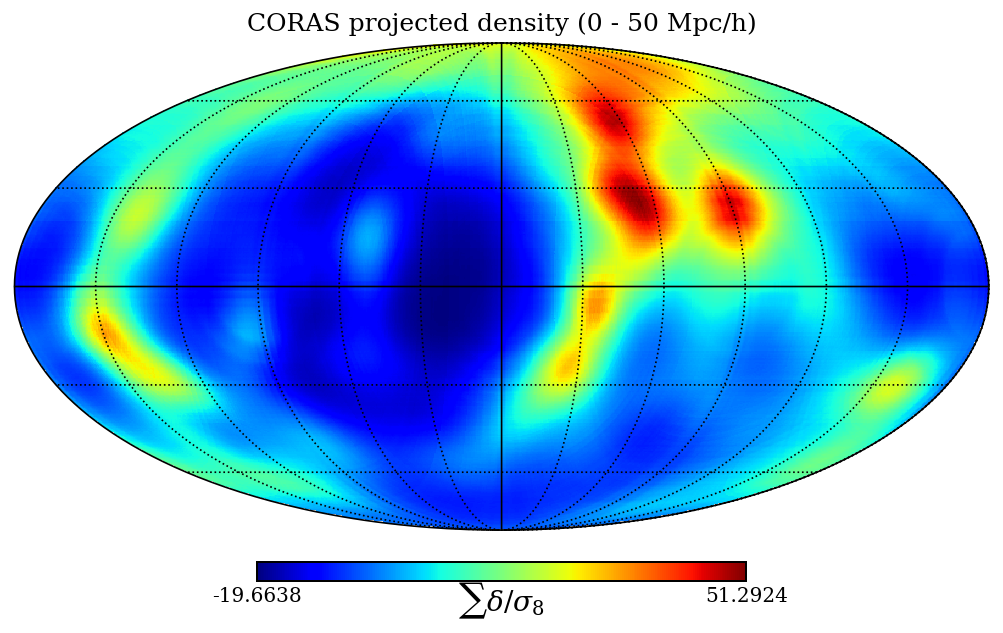

In [38]:
hp.mollview(map_0_50_raw, title="CORAS projected density (0 - 50 Mpc/h)", cmap="jet", unit=r"$\sum \delta/\sigma_8$")

hp.graticule()
plt.show()

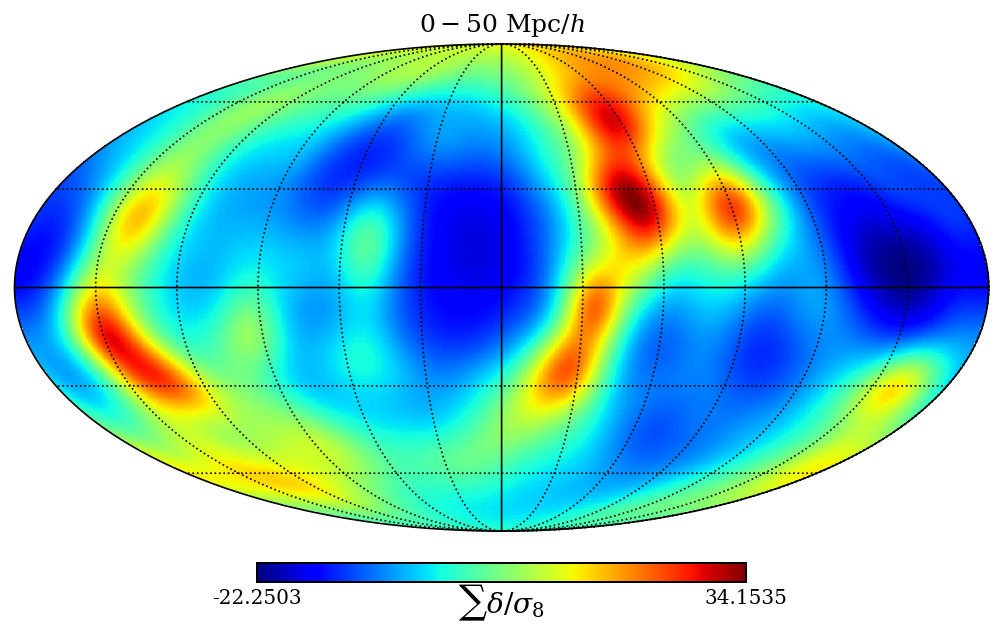

In [39]:
map_0_50_clean = hp.remove_dipole(map_0_50_raw, fitval=False)

FWHM_DEG = 9.16
map_0_50_final = hp.smoothing(map_0_50_clean, fwhm=np.radians(FWHM_DEG))

hp.mollview(map_0_50_final, title=r"$0-50\ \mathrm{Mpc}/h$", cmap="jet", unit=r"$\sum \delta/\sigma_8$")
hp.graticule()
plt.show()

In [47]:
mapa_A = map_0_50_final.copy()

validos = np.isfinite(mapa_A) & (mapa_A != hp.UNSEEN)

umbral_90 = np.percentile(mapa_A[validos], 90)
mask_top10 = validos & (mapa_A >= umbral_90)

print("número de píxeles en el 10%:", mask_top10.sum())

mapa_A_top10 = np.full_like(mapa_A, hp.UNSEEN)
mapa_A_top10[mask_top10] = mapa_A[mask_top10]

número de píxeles en el 10%: 5033165


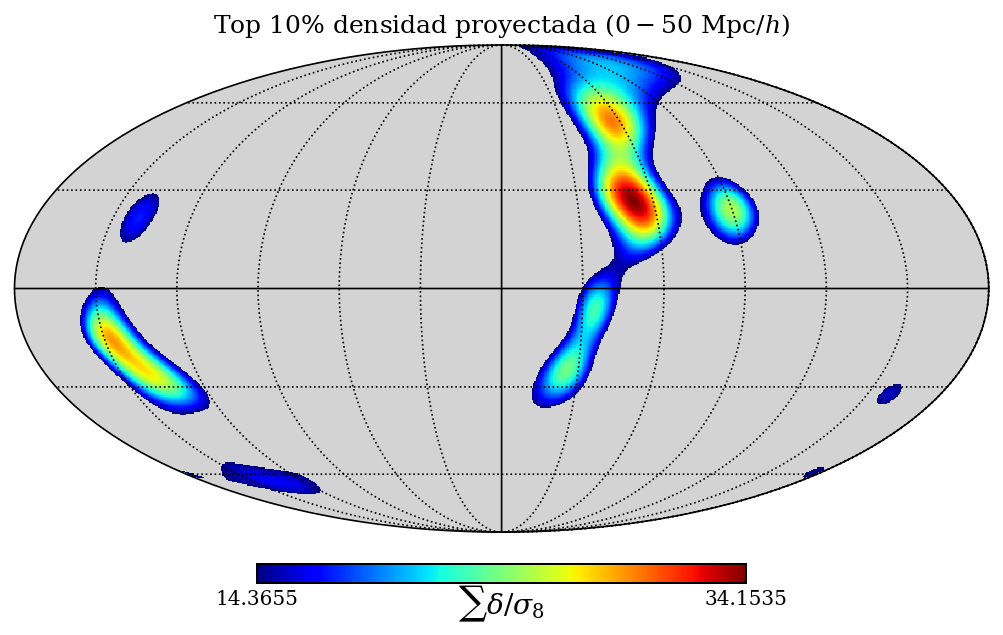

In [48]:
cmap = plt.get_cmap("jet").copy()
cmap.set_bad("lightgray")
hp.mollview(mapa_A_top10, title=r"Top 10% densidad proyectada ($0-50\ \mathrm{Mpc}/h$)", cmap="jet", unit=r"$\sum \delta/\sigma_8$", badcolor="lightgray", bgcolor="white")
hp.graticule()
plt.show()

Pixeles válidos: 42,399,813 / 50,331,648


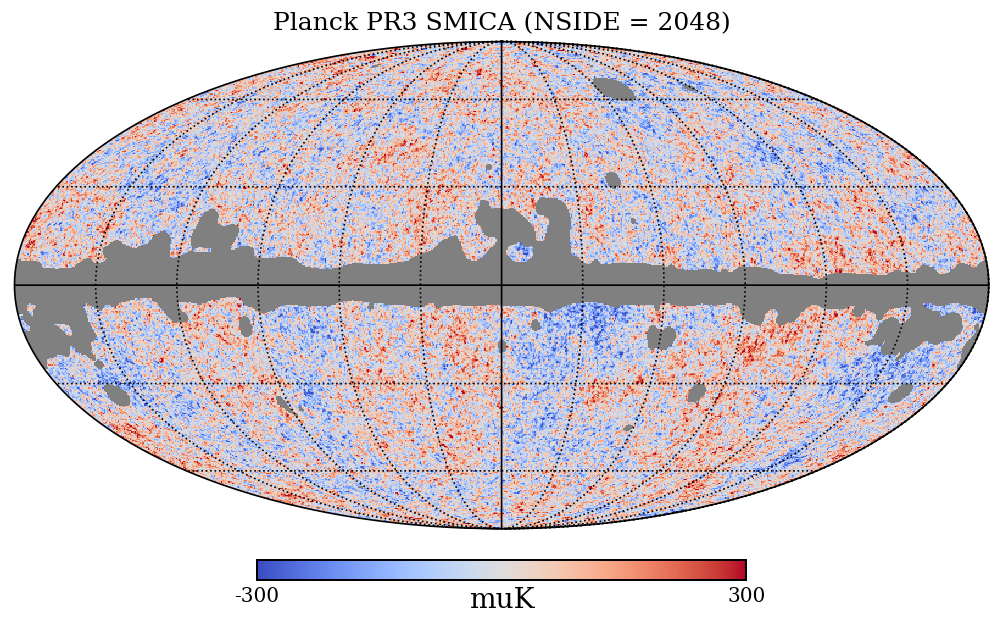

In [49]:
NSIDE = 2048
FITS_SMICA = '/home/barbarantares/Documentos/CMB/COM_CMB_IQU-smica_2048_R3.00_full.fits'
mapa_smica = hp.read_map(FITS_SMICA, field=0, nest=True)
mask_smica = hp.read_map(FITS_SMICA, field=3, nest=True)
mapa_smica  = hp.reorder(mapa_smica,  n2r=True)
mask_smica = hp.reorder(mask_smica, n2r=True)
mapa_smica = mapa_smica * 1e6

BAD_DATA = -1.6375e30

mapa_smica[mask_smica == 0] = hp.UNSEEN
print(f"Pixeles válidos: {(mapa_smica != hp.UNSEEN).sum():,} / {len(mapa_smica):,}")

hp.mollview(mapa_smica, title='Planck PR3 SMICA (NSIDE = 2048)', cmap='coolwarm', unit='muK', min=-300, max=300)
hp.graticule()
plt.show()

Píxeles top 10% CORAS originales: 5033165
Píxeles top 10% CORAS después máscara Planck: 4586036


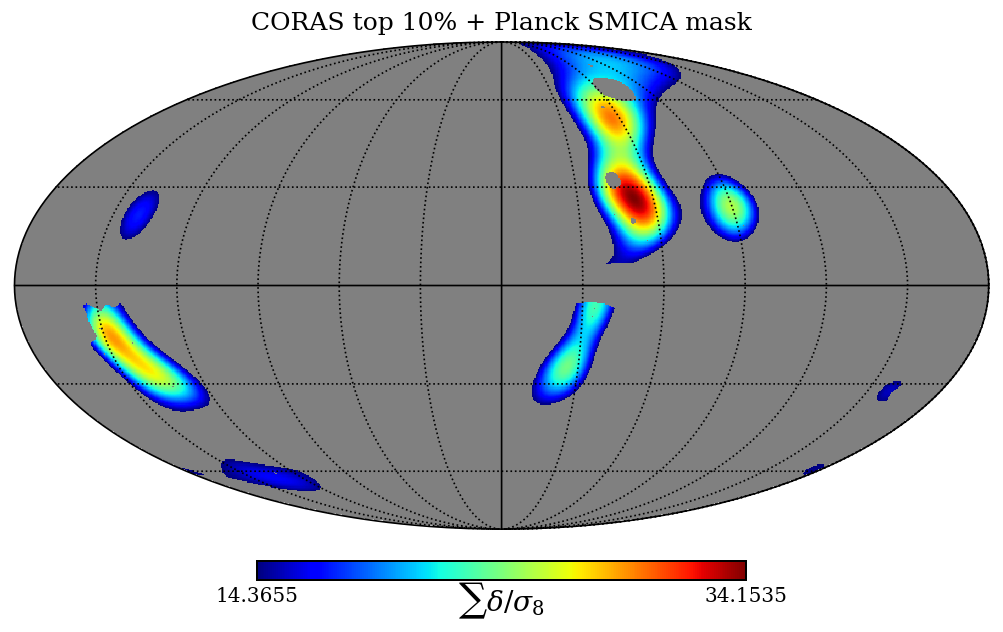

In [50]:
# ============================================================
# Aplicar máscara de Planck al top 10% de CORAS
# ============================================================

mask_planck = mask_smica != 0

mask_corass_planck = mask_top10 & mask_planck

mapa_A_top10_planck = np.full_like(mapa_A, hp.UNSEEN)
mapa_A_top10_planck[mask_corass_planck] = mapa_A[mask_corass_planck]

print("Píxeles top 10% CORAS originales:", mask_top10.sum())
print("Píxeles top 10% CORAS después máscara Planck:", mask_corass_planck.sum())

hp.mollview(
    mapa_A_top10_planck,
    title=r"CORAS top 10% + Planck SMICA mask",
    cmap="jet",
    unit=r"$\sum \delta/\sigma_8$"
)

hp.graticule()
plt.show()

In [51]:
cat = Table.read("/home/barbarantares/Documentos/CMB/2mrs_v240/catalog/2mrs_1175_done.fits")

print(f"Total de galaxias cargadas: {len(cat):,}")
print(cat.colnames)

k_c   = np.ma.asarray(cat["MKC"], dtype=float).filled(np.nan)
b_gal = np.ma.asarray(cat["GLAT"], dtype=float).filled(np.nan)
v_all = np.ma.asarray(cat["V"], dtype=float).filled(np.nan)

mask = ((k_c <= 11.254) & (np.abs(b_gal) > 10))
muestra = cat[mask]

print(f"Galaxias en la submuestra final: {len(muestra):,}")

def col_float(tabla, nombre):
    return np.ma.asarray(tabla[nombre], dtype=float).filled(np.nan)

ra = col_float(muestra, "RA")
dec = col_float(muestra, "DEC")
l = col_float(muestra, "GLON")
b = col_float(muestra, "GLAT")
k_c = col_float(muestra, "MKC")
h_c = col_float(muestra, "MHC")
j_c = col_float(muestra, "MJC")
e_bv = col_float(muestra, "EBV")
ba = col_float(muestra, "BA")
r_iso = col_float(muestra, "RISO")
v = col_float(muestra, "V")
e_v = col_float(muestra, "EV")

z = v / 299_792.458
d_Mpc = v / 70.0

Total de galaxias cargadas: 43,533
['TMID', 'RA', 'DEC', 'GLON', 'GLAT', 'MKC', 'MHC', 'MJC', 'MKTC', 'MHTC', 'MJTC', 'EKC', 'EHC', 'EJC', 'EKTC', 'EHTC', 'EJTC', 'EBV', 'RISO', 'RTOT', 'BA', 'FLAGS', 'TYPE', 'TYPESRC', 'V', 'EV', 'VCAT', 'VSRC', 'CATID']
Galaxias en la submuestra final: 20,860


In [52]:

theta_gal = np.radians(90.0 - b)
phi_gal = np.radians(np.mod(l, 360.0))

pix_gal = hp.ang2pix(NSIDE, theta_gal, phi_gal)

mask_en_top10_planck = (
    np.isfinite(mapa_A_top10_planck[pix_gal]) &
    (mapa_A_top10_planck[pix_gal] != hp.UNSEEN)
)

print(f"Galaxias totales de la muestra: {len(muestra):,}")
print(f"Galaxias dentro de CORAS top 10% + máscara Planck: {mask_en_top10_planck.sum():,}")
print(f"Fracción: {100 * mask_en_top10_planck.mean():.2f}%")

Galaxias totales de la muestra: 20,860
Galaxias dentro de CORAS top 10% + máscara Planck: 4,071
Fracción: 19.52%


In [53]:
muestra_top10_planck = muestra[mask_en_top10_planck]

l_top10 = l[mask_en_top10_planck]
b_top10 = b[mask_en_top10_planck]
v_top10 = v[mask_en_top10_planck]

print(f"Número final de galaxias: {len(muestra_top10_planck):,}")

Número final de galaxias: 4,071


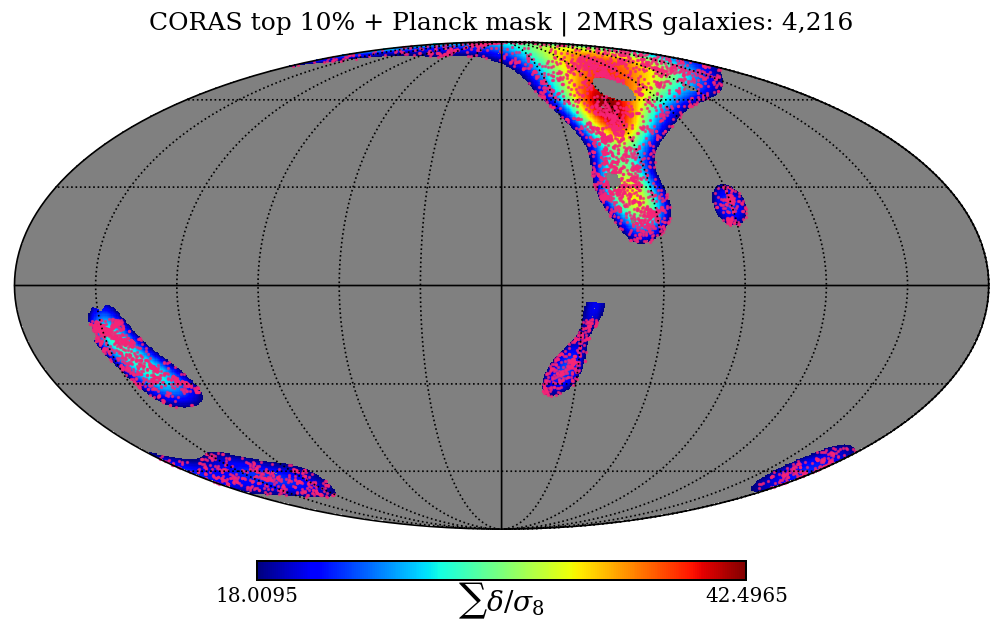

In [24]:
hp.mollview(
    mapa_A_top10_planck,
    title=f"CORAS top 10% + Planck mask | 2MRS galaxies: {mask_en_top10_planck.sum():,}",
    cmap="jet",
    unit=r"$\sum \delta/\sigma_8$"
)

hp.graticule()

hp.projscatter(
    theta_gal[mask_en_top10_planck],
    phi_gal[mask_en_top10_planck],
    lonlat=False,
    s=1,
    c="#F62477",
    alpha=0.7
)

plt.show()

In [54]:
theta_gal = np.radians(90.0 - b)
phi_gal = np.radians(np.mod(l, 360.0))

pix_gal = hp.ang2pix(NSIDE, theta_gal, phi_gal)


mask_top10_planck_gal = (
    np.isfinite(mapa_A_top10_planck[pix_gal]) &
    (mapa_A_top10_planck[pix_gal] != hp.UNSEEN)
)

theta_gal_top10 = theta_gal[mask_top10_planck_gal]
phi_gal_top10 = phi_gal[mask_top10_planck_gal]
v_top10 = v[mask_top10_planck_gal]

print(f"Galaxias 2MRS totales: {len(v):,}")
print(f"Galaxias en CORAS top 10% + Planck: {len(v_top10):,}")

Galaxias 2MRS totales: 20,860
Galaxias en CORAS top 10% + Planck: 4,071


In [55]:
mask_A = (v_top10 > 0) & (v_top10 <= 5000)

theta_A = theta_gal_top10[mask_A]
phi_A = phi_gal_top10[mask_A]
v_A = v_top10[mask_A]

print(f"Galaxias Grupo A en CORAS top 10% + Planck: {len(v_A):,}")

Galaxias Grupo A en CORAS top 10% + Planck: 2,017


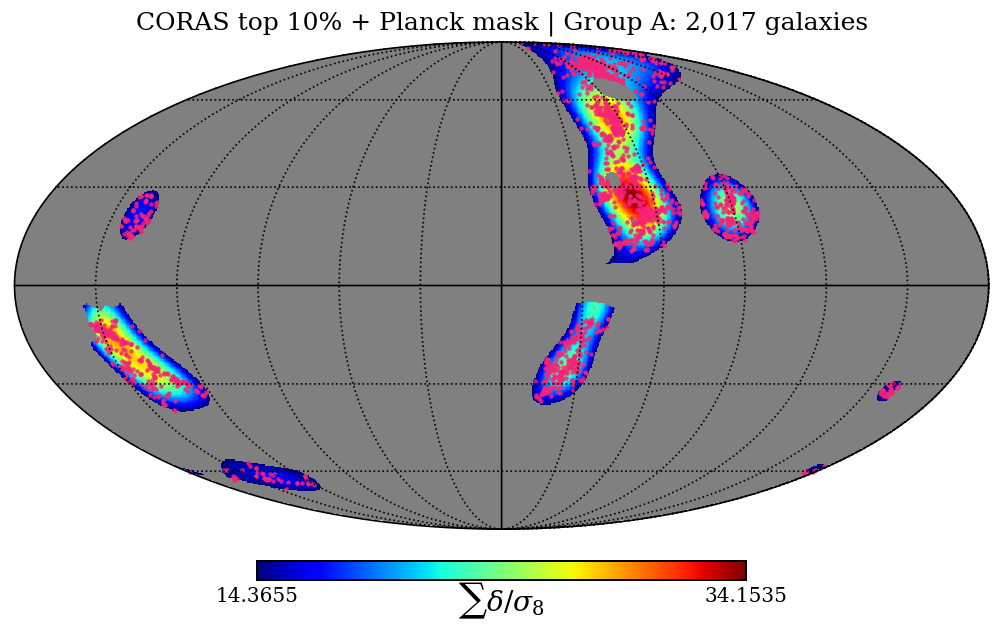

In [56]:
hp.mollview(
    mapa_A_top10_planck,
    title=f"CORAS top 10% + Planck mask | Group A: {len(v_A):,} galaxies",
    cmap="jet",
    unit=r"$\sum \delta/\sigma_8$"
)

hp.graticule()

hp.projscatter(
    theta_A,
    phi_A,
    s=3,
    c="#F62477",
    alpha=0.7
)
plt.savefig("/home/barbarantares/Descargas/FSAYA/1.png", dpi=600, bbox_inches="tight")

plt.show()

In [34]:
n_puntos_A = len(theta_A)

r_inicial = 0.2
r_final = 30.2
ancho_anillo = 0.5

bordes_radiales = np.arange(r_inicial,r_final + ancho_anillo,ancho_anillo)
radios_internos = bordes_radiales[:-1]
radios_externos = bordes_radiales[1:]
radios_medios = (radios_internos + radios_externos) / 2

n_anillos = len(radios_medios)

print("Número de galaxias seleccionadas:",n_puntos_A)
print("Número de anillos:",n_anillos)

pix_gal_A = hp.ang2pix(NSIDE,theta_A,phi_A)

filas_perfiles = []

for i in tqdm(range(n_puntos_A),desc="Calculando perfil radial por galaxia"):
    vec_i = hp.ang2vec(theta_A[i],phi_A[i])
    discos = [hp.query_disc(NSIDE,vec_i,np.radians(r),inclusive=True) for r in bordes_radiales]

    perfil_i = np.full(n_anillos,np.nan,dtype=np.float64)
    suma_npix_i = np.zeros(n_anillos,dtype=np.int64)

    for j in range(n_anillos):
        pix_anillo = np.setdiff1d(discos[j + 1],discos[j],assume_unique=True)
        valores_anillo = mapa_smica[pix_anillo]
        mask_validos = np.isfinite(valores_anillo) & (valores_anillo != hp.UNSEEN)
        valores_validos = valores_anillo[mask_validos]

        if len(valores_validos) > 0:
            perfil_i[j] = np.mean(valores_validos)
            suma_npix_i[j] = len(valores_validos)

    for j in range(n_anillos):
        fila = {"galaxy_id":i + 1,"pixel_galaxia":pix_gal_A[i],"theta_rad":theta_A[i],"phi_rad":phi_A[i],"v_km_s":v_A[i],"radio_interno_deg":radios_internos[j],"radio_externo_deg":radios_externos[j],"radio_medio_deg":radios_medios[j],"perfil_uK":perfil_i[j],"suma_npix":suma_npix_i[j],"anillo_valido":suma_npix_i[j] > 0}
        filas_perfiles.append(fila)

csv_individual = Path("/home/barbarantares/Documentos/SESSION/CORAS_more_dense.csv")

df_perfiles_galaxias = pd.DataFrame(filas_perfiles)
df_perfiles_galaxias.to_csv(csv_individual,index=False)

print("CSV guardado en:")
print(csv_individual)
print("Número de filas:",len(df_perfiles_galaxias))

Número de galaxias seleccionadas: 2017
Número de anillos: 60


Calculando perfil radial por galaxia: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2017/2017 [26:22<00:00,  1.27it/s]


CSV guardado en:
/home/barbarantares/Documentos/SESSION/CORAS_more_dense.csv
Número de filas: 121020


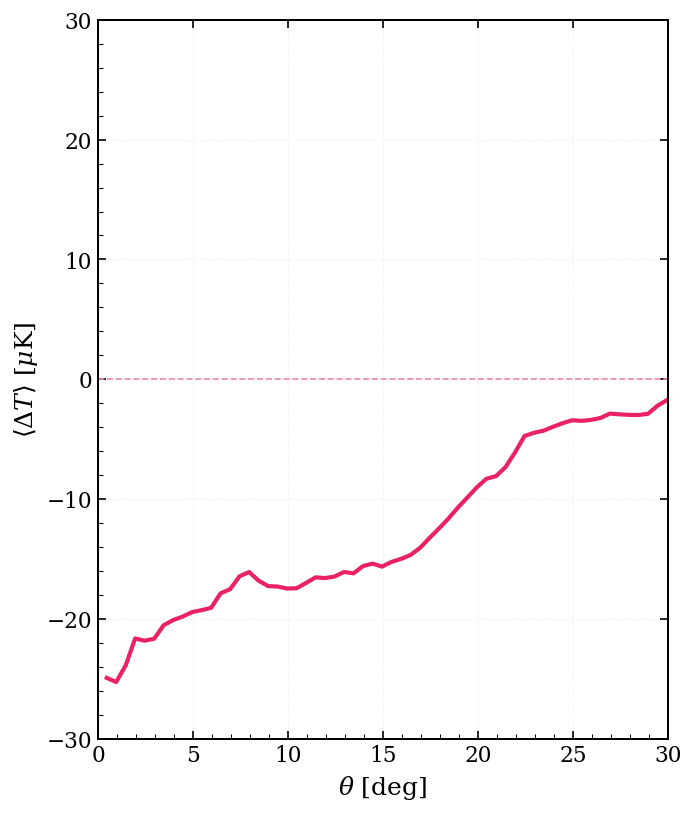

In [57]:
csv_individual = Path("/home/barbarantares/Documentos/SESSION/CORAS_more_dense.csv")
df_ind = pd.read_csv(csv_individual)

df_promedio = df_ind.groupby("radio_medio_deg",as_index=False).agg(perfil_promedio_uK=("perfil_uK","mean"))

plt.figure(figsize=(6,7))
plt.plot(df_promedio["radio_medio_deg"],df_promedio["perfil_promedio_uK"],lw=2.5,c='#EA2264')

plt.xlabel(r"$\theta$ [deg]",fontsize=15)
plt.ylabel(r"$\langle \Delta T \rangle$ [$\mu$K]",fontsize=15)
plt.axhline(0,color="#EF88AD",lw=1,linestyle="--")
plt.tick_params(labelsize=13)
plt.grid(alpha=0.3)
plt.ylim(-30,30)
plt.xlim(0,30)
plt.tick_params(labelsize=13,top=True,right=True,direction="in")

plt.tight_layout()
plt.savefig("/home/barbarantares/Documentos/SESSION/1.png", dpi=600, bbox_inches="tight")

plt.show()

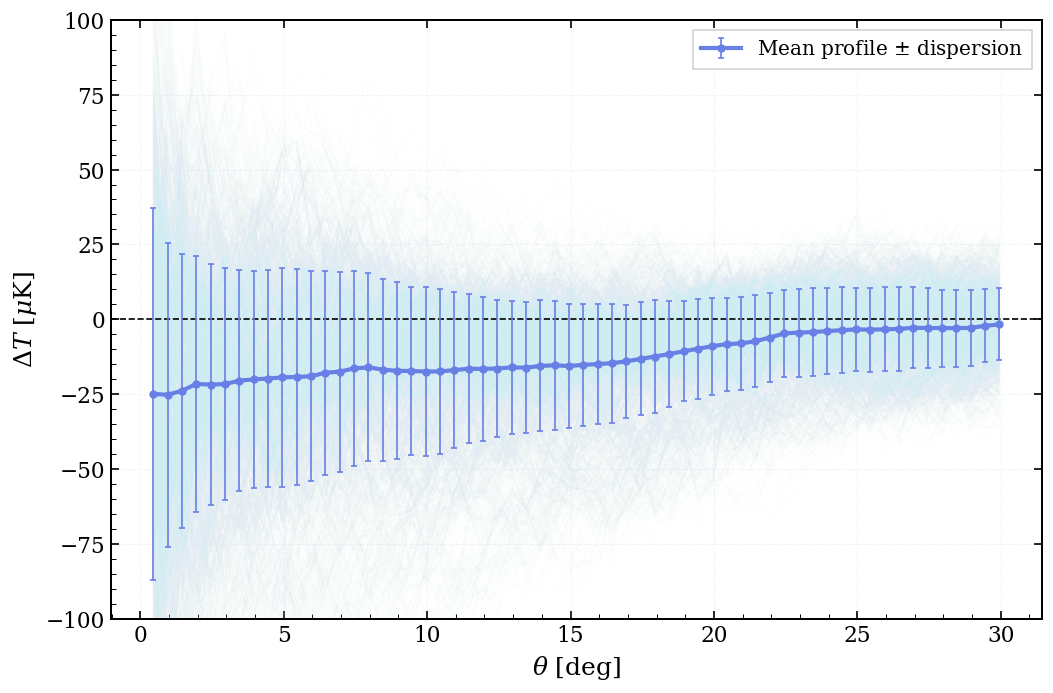

In [58]:
csv_individual = Path("/home/barbarantares/Documentos/SESSION/CORAS_more_dense.csv")
df_ind = pd.read_csv(csv_individual)

df_promedio = df_ind.groupby("radio_medio_deg",as_index=False).agg(
    perfil_promedio_uK=("perfil_uK","mean"),
    dispersion_uK=("perfil_uK","std")
)

plt.figure(figsize=(9,6))

for galaxy_id,df_gal in df_ind.groupby("galaxy_id"):
    plt.plot(
        df_gal["radio_medio_deg"],
        df_gal["perfil_uK"],
        color="#CFECF3",
        lw=0.5,
        alpha=0.05
    )

plt.errorbar(
    df_promedio["radio_medio_deg"],
    df_promedio["perfil_promedio_uK"],
    yerr=df_promedio["dispersion_uK"],
    color="#687FE5",
    marker="o",
    markersize=4,
    lw=2.5,
    elinewidth=1,
    capsize=2,
    label=r"Mean profile $\pm$ dispersion",
    zorder=10
)

plt.xlabel(r"$\theta$ [deg]",fontsize=15)
plt.ylabel(r"$\Delta T$ [$\mu$K]",fontsize=15)

plt.axhline(0,color="black",lw=1,linestyle="--")
plt.tick_params(labelsize=13,top=True,right=True,direction="in")
plt.grid(alpha=0.3)
plt.legend()
plt.ylim(-100,100)
plt.tight_layout()
plt.savefig("/home/barbarantares/Documentos/SESSION/dispersion.png", dpi=600, bbox_inches="tight")

plt.show()

# SEPARACION DE 3 GRADOS

In [44]:
# ============================================================
# Selección con separación angular mínima de 3°
# ============================================================

sep_min_deg = 3.0
sep_min_rad = np.radians(sep_min_deg)

vec_gal = hp.ang2vec(theta_A,phi_A)

indices_sep3 = []

for i in range(len(theta_A)):
    if len(indices_sep3) == 0:
        indices_sep3.append(i)
        continue

    productos = np.dot(vec_gal[indices_sep3],vec_gal[i])
    productos = np.clip(productos,-1.0,1.0)
    separaciones = np.arccos(productos)

    if np.all(separaciones >= sep_min_rad):
        indices_sep3.append(i)

indices_sep3 = np.array(indices_sep3,dtype=int)

theta_A_sep3 = theta_A[indices_sep3]
phi_A_sep3 = phi_A[indices_sep3]
v_A_sep3 = v_A[indices_sep3]

print("Número de galaxias originales:",len(theta_A))
print("Número de galaxias con separación mínima de 3°:",len(theta_A_sep3))

Número de galaxias originales: 2017
Número de galaxias con separación mínima de 3°: 200


In [45]:
n_puntos_A = len(theta_A_sep3)

r_inicial = 0.2
r_final = 30.2
ancho_anillo = 0.5

bordes_radiales = np.arange(r_inicial,r_final + ancho_anillo,ancho_anillo)
radios_internos = bordes_radiales[:-1]
radios_externos = bordes_radiales[1:]
radios_medios = (radios_internos + radios_externos) / 2

n_anillos = len(radios_medios)

print("Número de galaxias seleccionadas:",n_puntos_A)
print("Número de anillos:",n_anillos)

pix_gal_A = hp.ang2pix(NSIDE,theta_A_sep3,phi_A_sep3)

filas_perfiles = []

for i in tqdm(range(n_puntos_A),desc="Calculando perfil radial por galaxia"):
    vec_i = hp.ang2vec(theta_A_sep3[i],phi_A_sep3[i])
    discos = [hp.query_disc(NSIDE,vec_i,np.radians(r),inclusive=True) for r in bordes_radiales]

    perfil_i = np.full(n_anillos,np.nan,dtype=np.float64)
    suma_npix_i = np.zeros(n_anillos,dtype=np.int64)

    for j in range(n_anillos):
        pix_anillo = np.setdiff1d(discos[j + 1],discos[j],assume_unique=True)
        valores_anillo = mapa_smica[pix_anillo]
        mask_validos = np.isfinite(valores_anillo) & (valores_anillo != hp.UNSEEN)
        valores_validos = valores_anillo[mask_validos]

        if len(valores_validos) > 0:
            perfil_i[j] = np.mean(valores_validos)
            suma_npix_i[j] = len(valores_validos)

    for j in range(n_anillos):
        fila = {"galaxy_id":i + 1,"pixel_galaxia":pix_gal_A[i],"theta_rad":theta_A_sep3[i],"phi_rad":phi_A_sep3[i],"v_km_s":v_A_sep3[i],"radio_interno_deg":radios_internos[j],"radio_externo_deg":radios_externos[j],"radio_medio_deg":radios_medios[j],"perfil_uK":perfil_i[j],"suma_npix":suma_npix_i[j],"anillo_valido":suma_npix_i[j] > 0}
        filas_perfiles.append(fila)

csv_individual = Path("/home/barbarantares/Documentos/SESSION/CORAS_more_dense_sep3deg.csv")

df_perfiles_galaxias = pd.DataFrame(filas_perfiles)
df_perfiles_galaxias.to_csv(csv_individual,index=False)

print("CSV guardado en:")
print(csv_individual)
print("Número de galaxias:",n_puntos_A)
print("Número de filas:",len(df_perfiles_galaxias))

Número de galaxias seleccionadas: 200
Número de anillos: 60


Calculando perfil radial por galaxia: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [02:18<00:00,  1.45it/s]

CSV guardado en:
/home/barbarantares/Documentos/SESSION/CORAS_more_dense_sep3deg.csv
Número de galaxias: 200
Número de filas: 12000


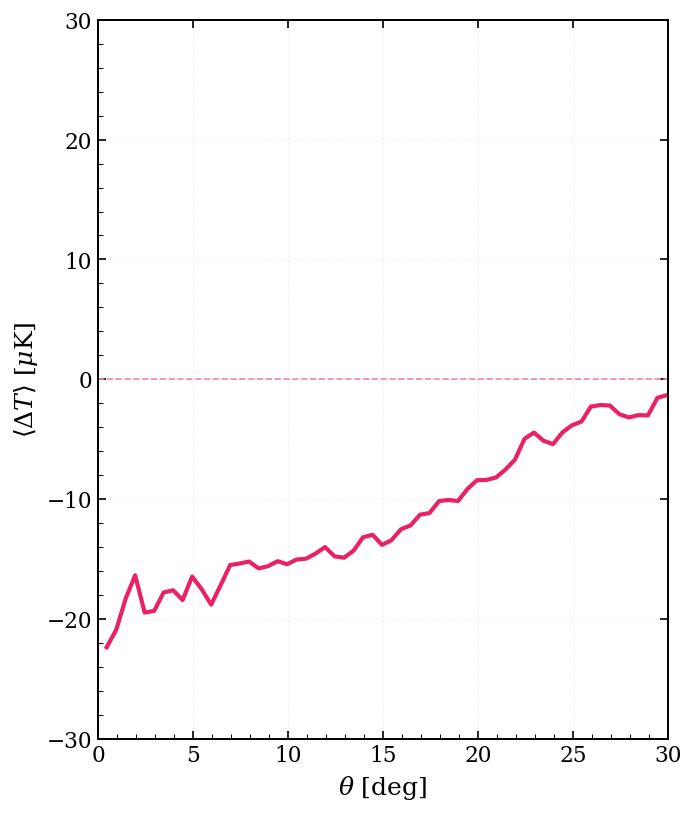

In [59]:
csv_individual = Path("/home/barbarantares/Documentos/SESSION/CORAS_more_dense_sep3deg.csv")
df_ind = pd.read_csv(csv_individual)

df_promedio = df_ind.groupby("radio_medio_deg",as_index=False).agg(perfil_promedio_uK=("perfil_uK","mean"))

plt.figure(figsize=(6,7))
plt.plot(df_promedio["radio_medio_deg"],df_promedio["perfil_promedio_uK"],lw=2.5,c='#EA2264')

plt.xlabel(r"$\theta$ [deg]",fontsize=15)
plt.ylabel(r"$\langle \Delta T \rangle$ [$\mu$K]",fontsize=15)
plt.axhline(0,color="#EF88AD",lw=1,linestyle="--")
plt.tick_params(labelsize=13)
plt.grid(alpha=0.3)
plt.ylim(-30,30)
plt.xlim(0,30)
plt.tick_params(labelsize=13,top=True,right=True,direction="in")

plt.tight_layout()
plt.savefig("/home/barbarantares/Documentos/SESSION/1.png", dpi=600, bbox_inches="tight")

plt.show()